# SCSAP — Tutorial notebook

End-to-end walk through the spatial-cell analysis pipeline used in the paper.
Heavy feature-extraction steps (per-image `psi_k` and local-density sweeps
across all cell-type combinations and bond radii) are GPU-expensive and
pre-computed — the CSVs under
`data/features/<dataset>/data_filtered_<radius>.csv` are the outputs of that
run. The downstream statistical analyses (KS testing, random-forest
classification, HSIC independence test) are reproduced here directly from
those CSVs, using the helpers in `src/*.py`.

## Pipeline at a glance

1. **Load raw cells** — per-image dataframes for both datasets (CRC, CP_PDAC).
2. **Bond graphs** — neighbour graphs at a few radii for one image per
   `(dataset, pathology)`.
3. **Per-image feature maps** — local density and `|psi_6|` coloured by cell
   position on four example images.
4. **Read pre-computed features** — per-image aggregated CSVs at the chosen
   radius.
5. **KS test** — paper-figure replication: two-sample KS between pathology
   groups, plotted as filled KDEs.
6. **Random-forest classification** — 5-fold CV across feature subsets
   (all / density / psi / top-20) with bootstrap confidence intervals.
7. **HSIC** — independence test between the psi and density feature blocks
   swept over every available radius.

> Datasets used throughout:
> **CRC** (140 images, CLR vs DII pathology) and
> **CP_PDAC** (199 images, CP vs PDAC pathology).
Note: these datasets are not made available for public use yet. Simulate_data.py offers a script to generate
data in a similar structure to the input data used in the paper.


## 1 · Load the raw cell-level data

Each row of the raw CSV is one cell with `(x, y)` coordinates, a cell-type
label, a pathology label, and image / patient identifiers. `load_dataset`
groups by `image_id`, deduplicates overlapping positions, builds a stable
string→int cell-type encoding, and returns `{image_id: dataframe}` together
with the shared encoding.


In [1]:
# Load the unified per-cell CSVs for both datasets. `load_dataset`
# returns a `{image_id: DataFrame}` dict plus the cell-type encoding,
# so a single function call handles all 140 + 199 images.
import sys
from pathlib import Path

# Notebook lives in `notebooks/`; add the project root so `import src.*` works.
sys.path.insert(0, str(Path.cwd().parent))

from src.preprocessing import load_dataset

# Global seed, matching configs/default.yaml. Passed into every stochastic
# step below (RF cross-validation, HSIC permutation test) so the whole
# notebook reproduces from one place.
RANDOM_STATE = 42

RAW = Path.cwd().parent / "data" / "raw"
DATASET_PATHS = {
    "CRC":     RAW / "CRC_unified.csv",
    "CP_PDAC": RAW / "CP_PDAC_unified.csv",
}

datasets = {}  # name -> (images dict, encoding)
for name, path in DATASET_PATHS.items():
    images, encoding = load_dataset(path)
    datasets[name] = (images, encoding)

    total_cells = sum(len(df) for df in images.values())
    pathologies = sorted({df["pathology"].iloc[0] for df in images.values()})
    print(f"=== {name} ===")
    print(f"  images:       {len(images)}")
    print(f"  cells:        {total_cells:,}")
    print(f"  cell types:   {len(encoding)}  ->  {list(encoding)}")
    print(f"  pathologies:  {pathologies}")
    print()

=== CRC ===
  images:       140
  cells:        258,385
  cell types:   17  ->  ['B cells', 'CD163+ macros', 'CD4+ T cells', 'CD68+ macros', 'CD8+ T cells', 'NK cells', 'Tregs', 'adipocytes', 'generic immune', 'granulocytes', 'memory CD4+ T', 'plasma cells', 'smooth muscle', 'stroma', 'tumor cells', 'undefined', 'vasculature']
  pathologies:  ['CLR', 'DII']

=== CP_PDAC ===
  images:       199
  cells:        267,544
  cell types:   5  ->  ['APC', 'CTL', 'Epi', 'THelper', 'Treg']
  pathologies:  ['CP', 'PDAC']



## 2 · Bond graphs at selected radii

For one image per `(dataset, pathology)`, draw the freud neighbour graph at a
couple of bond radii (60 and 120 px) to give an intuition for what "neighbour"
means before any feature extraction begins.

`_radius_nlist` in `src/features.py` builds the `NeighborList`; each
(query-point, point) pair is rendered as a line segment, with cells overlaid
and coloured by cell type.


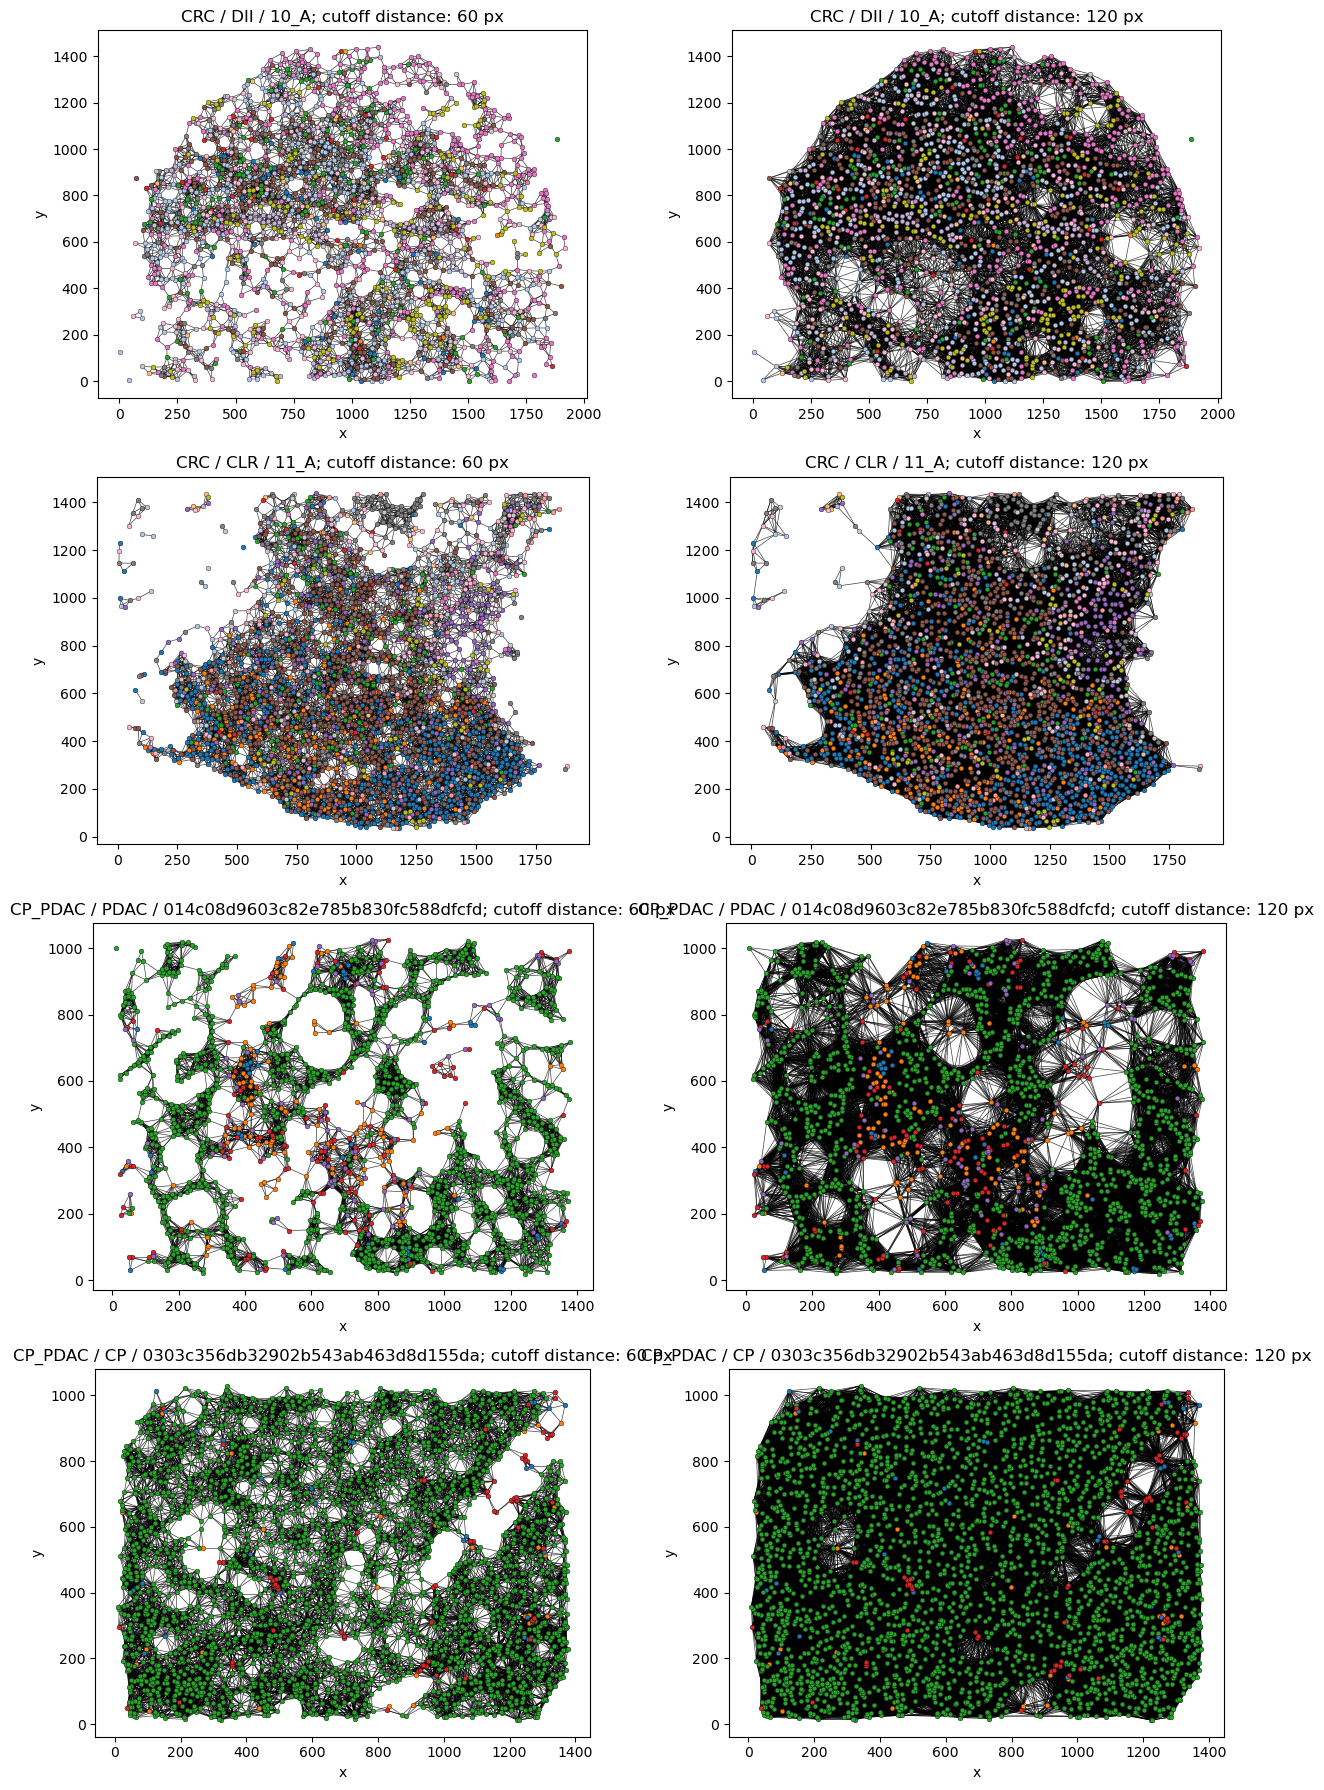

In [2]:
# Bond graphs at selected radii for one image per (dataset, pathology).
# `src.features._radius_nlist(box, points, cutoff)` returns a freud
# NeighborList; we draw a line segment for each (query_point, point) pair,
# then overlay the cells coloured by cell type.

import numpy as np
from matplotlib.collections import LineCollection
import matplotlib.pyplot as plt
from src.features import _radius_nlist
from src.preprocessing import build_freud_system

# defining cell colors for plotting
PANC_COLORS = {
    "APC": "tab:orange",
    "CTL": "tab:blue",
    "Epi": "tab:green",
    "THelper": "tab:red",
    "Treg": "tab:purple",
}

(images_CRC, encoding_CRC) = datasets['CRC']
CRC_CELL_TYPES = encoding_CRC

CRC_COLORS = {
    cell_type: plt.cm.tab20.colors[idx]
    for idx, cell_type in enumerate(CRC_CELL_TYPES)
}

CELL_COLORS = {
    **PANC_COLORS,
    **CRC_COLORS,
}

BOND_CUTOFFS = [60, 120]

# Pick one image per pathology from each dataset.
selections = []  # list of (dataset_name, pathology, image_id, df)
for name, (images, _) in datasets.items():
    seen = set()
    for image_id, df in images.items():
        pathology = df["pathology"].iloc[0]
        if pathology in seen:
            continue
        seen.add(pathology)
        selections.append((name, pathology, image_id, df))

fig, axes = plt.subplots(len(selections),
                         len(BOND_CUTOFFS),
                         figsize=(13, 4.5 * len(selections)),
                        )


for row, (name, pathology, image_id, df) in enumerate(selections):
    box, points = build_freud_system(df)

    for col, cutoff in enumerate(BOND_CUTOFFS):
        ax = axes[row, col]
        nlist = _radius_nlist(box, points, cutoff)
        bonds = np.unique(np.sort(nlist[:], axis=1), axis=0)

        # Draw bonds
        segments = points[bonds][:, :, :2]
        ax.add_collection(
            LineCollection(
                segments,
                colors="black",
                linewidths=0.5,
                alpha=0.75,
                zorder=1,
            )
        )

        # Draw cells colored by cell type
        for cell_type, group in df.groupby("cell_type"):
            label = str(cell_type).strip('"')
            color = CELL_COLORS.get(cell_type, CELL_COLORS.get(label, "gray"))

            ax.scatter(
                group["x"],
                group["y"],
                s=12,
                color=color,
                edgecolors="black",
                linewidths=0.25,
                label=f"{label}, n={len(group)}",
                zorder=2,
            )

        ax.set_title(
            f"{name} / {pathology} / {image_id}; cutoff distance: {cutoff} px"
        )
        ax.set_aspect("equal")
        ax.set_xlabel("x")
        ax.set_ylabel("y")

plt.tight_layout()
plt.show()

## 3 · Per-image feature maps

For one image per `(dataset, pathology)` combination, compute two features
at the default bond cutoff (`bond_cutoff = 60.0`) and colour each cell's
spatial position by them:

* `local_density` — local cell density in a disk of radius `bond_cutoff`.
* `|psi_6|` — modulus of the hexatic bond-orientational order parameter
  (k = 6).

Four images × two features → an 8-panel grid. These are the kinds of maps
used to motivate the bulk feature sweeps in the paper.


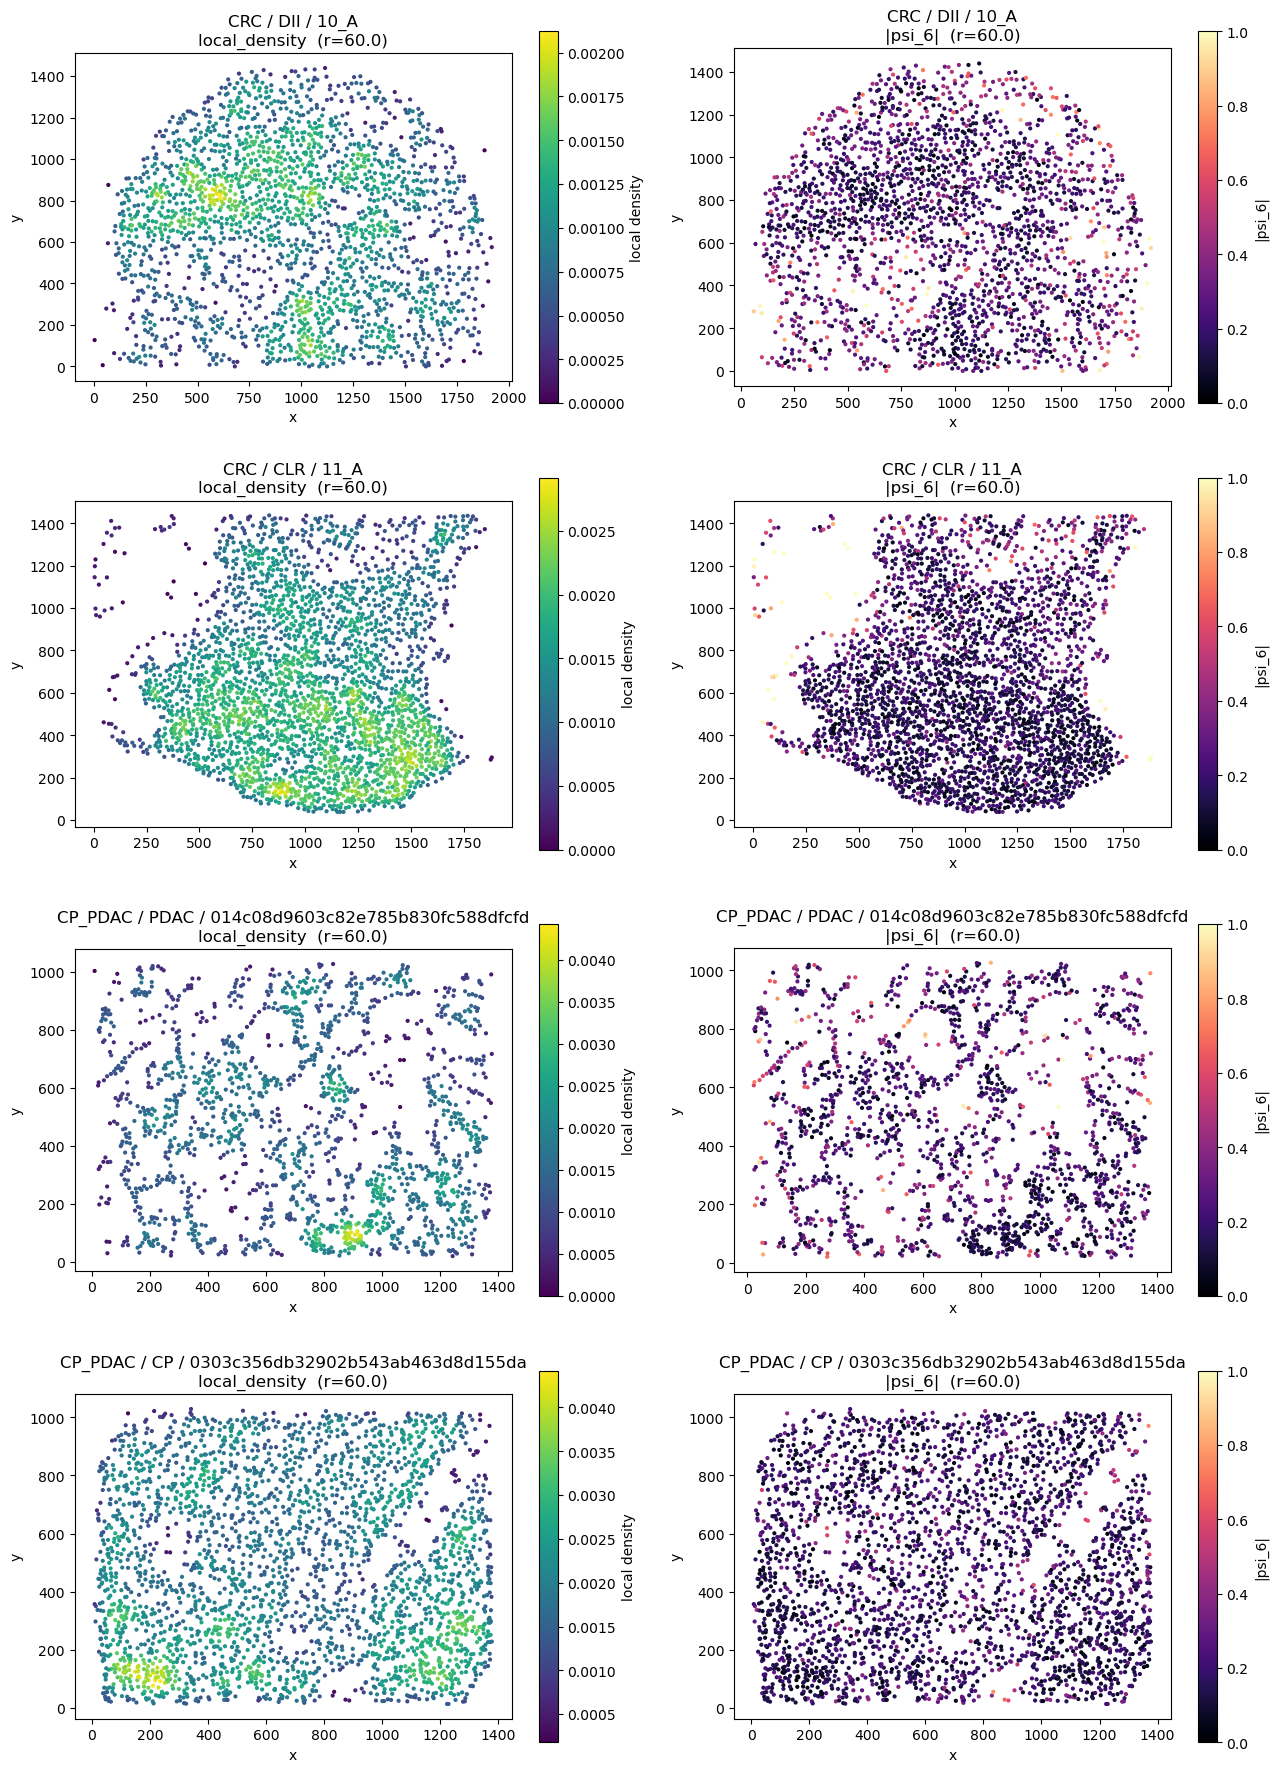

In [3]:
# Per-image feature maps for one image per (dataset, pathology) combination.
# We pick the first image we see in each pathology, compute local density and
# |psi_6| at the default bond cutoff, then scatter-plot the cells coloured by
# each feature.  4 images x 2 features = 8 panels.
import matplotlib.pyplot as plt

from src.features import compute_local_density, compute_katic_order

BOND_CUTOFF = 60.0   # configs/default.yaml
K = 6                # hexatic order parameter

# Pick one image per pathology from each dataset.
selections = []  # list of (dataset_name, pathology, image_id, df)
for name, (images, _) in datasets.items():
    seen = set()
    for image_id, df in images.items():
        pathology = df["pathology"].iloc[0]
        if pathology in seen:
            continue
        seen.add(pathology)
        selections.append((name, pathology, image_id, df))

fig, axes = plt.subplots(len(selections), 2, figsize=(13, 4.5 * len(selections)))

for row, (name, pathology, image_id, df) in enumerate(selections):
    cell_types = sorted(df["cell_type"].unique().tolist())

    # Adds a `local_density` column (one value per cell).
    df_feat = compute_local_density(df, cell_types=cell_types, cutoff=BOND_CUTOFF,
                                    include_neighbor_counts=False)
    # Adds `psi_{K}_all`, `psi_{K}_ngek`, `psi_{K}_nek` columns.
    df_feat = compute_katic_order(df_feat, cutoff=BOND_CUTOFF, k_values=[K])

    ax_ld = axes[row, 0]
    sc = ax_ld.scatter(df_feat["x"], df_feat["y"], c=df_feat["local_density"],
                       s=4, cmap="viridis")
    plt.colorbar(sc, ax=ax_ld, label="local density")
    ax_ld.set_title(f"{name} / {pathology} / {image_id}\nlocal_density  (r={BOND_CUTOFF})")
    ax_ld.set_aspect("equal")
    ax_ld.set_xlabel("x"); ax_ld.set_ylabel("y")

    ax_psi = axes[row, 1]
    sc = ax_psi.scatter(df_feat["x"], df_feat["y"], c=df_feat[f"psi_{K}_all"],
                        s=4, cmap="magma", vmin=0.0, vmax=1.0)
    plt.colorbar(sc, ax=ax_psi, label=f"|psi_{K}|")
    ax_psi.set_title(f"{name} / {pathology} / {image_id}\n|psi_{K}|  (r={BOND_CUTOFF})")
    ax_psi.set_aspect("equal")
    ax_psi.set_xlabel("x"); ax_psi.set_ylabel("y")

plt.tight_layout()
plt.show()


## 4 · Read pre-computed per-image features

Computing the full feature table from scratch is GPU-expensive — the per-image
CSVs at `data/features/<dataset>/data_filtered_<radius>.csv` are the cached
output of that pipeline. We pick one radius (`r = 240`, matching the radius
used in the paper figure replicated below) and load both datasets.

Available radii on disk: **30, 60, 90, 120, 180, 240**.


In [4]:
# Load the pre-computed per-image features for both datasets at one radius.
# Each row is one image; each column is one (cell-type-combo, feature)
# aggregated to a scalar (mean across cells in the image).
import pandas as pd

RADIUS = 240
FEATURES_DIR = Path.cwd().parent / "data" / "features"

FEATURE_PATHS = {
    "CRC":     FEATURES_DIR / "CRC"     / f"data_filtered_{RADIUS}.csv",
    "CP_PDAC": FEATURES_DIR / "CP_PDAC" / f"data_filtered_{RADIUS}.csv",
}

# Non-feature columns to exclude from any downstream feature lists.
META_COLS = ["job_id", "image_id", "pathology", "label", "dataset"]

feature_dfs = {}     # dataset name -> per-image feature dataframe
feature_cols = {}    # dataset name -> list of feature column names
for name, path in FEATURE_PATHS.items():
    df = pd.read_csv(path)
    feats = [c for c in df.columns if c not in META_COLS]
    feature_dfs[name] = df
    feature_cols[name] = feats

    print(f"=== {name}  (r={RADIUS}) ===")
    print(f"  images:    {len(df)}")
    print(f"  features:  {len(feats):,}")
    print(f"  by pathology: {df['pathology'].value_counts().to_dict()}")
    print()


=== CRC  (r=240) ===
  images:    140
  features:  16,893
  by pathology: {'DII': 72, 'CLR': 68}

=== CP_PDAC  (r=240) ===
  images:    199
  features:  1,714
  by pathology: {'PDAC': 143, 'CP': 56}



## 5 · KS test — paper figure replication

Two-sample Kolmogorov–Smirnov test comparing the two pathology groups on the
four features highlighted in the paper:

* **CP_PDAC** — local density of `Epi` cells, and `psi_8` on `Epi`.
* **CRC** — local density of `CD163+ macros` near `granulocytes`, and
  `psi_5` on the same pair.

`ks_test_per_feature` runs the test, `adjust_pvalues` appends
Benjamini–Hochberg (BH) and Benjamini–Yekutieli (BY) FDR-corrected p-values,
and `plot_ks_kde_grid` renders the filled-KDE comparison in the same style
as the paper figure.


=== CP_PDAC  (r=240) ===
                  feature  statistic      p_value   p_value_bh   p_value_by
local_density_Epi_240_Epi   0.743161 2.743017e-22 5.486034e-22 8.229051e-22
        psi_8_Epi_all_Epi   0.632345 1.113745e-15 1.113745e-15 1.670618e-15

=== CRC  (r=240) ===
                                                  feature  statistic      p_value   p_value_bh   p_value_by
local_density_CD163+ macros_granulocytes_240_granulocytes   0.465686 2.112836e-07 2.112836e-07 3.169254e-07
        psi_5_CD163+ macros_granulocytes_all_granulocytes   0.508987 8.394989e-09 1.678998e-08 2.518497e-08



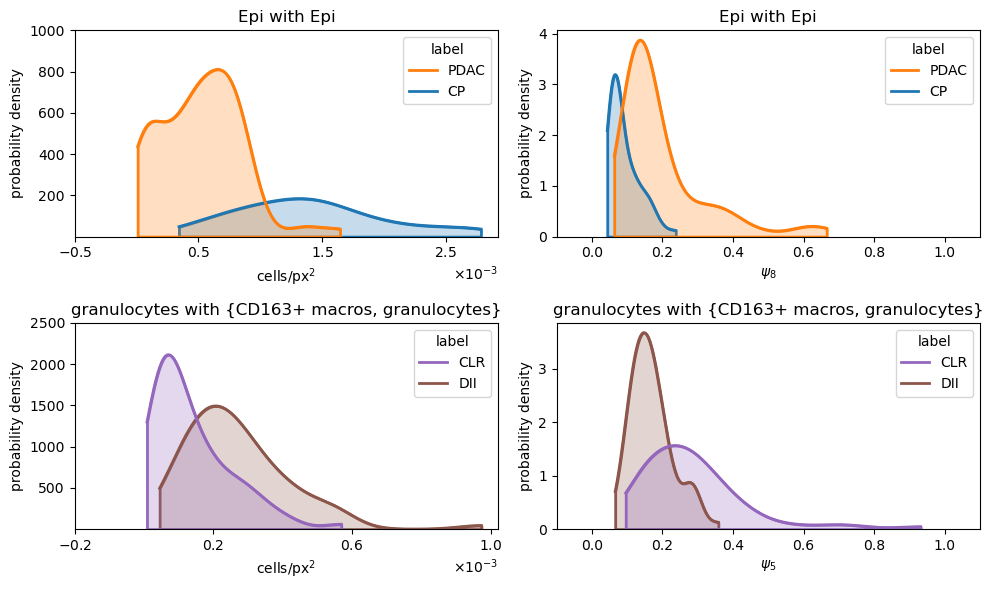

In [5]:
# KS test between the two pathology groups on the four features the paper
# figure highlights. `ks_test_per_feature` runs scipy's two-sample KS test
# per column; `adjust_pvalues` adds BH and BY FDR-corrected columns.
# `plot_ks_kde_grid` is a thin wrapper around seaborn.kdeplot that styles
# panels to match the paper figure (filled + outlined KDE, count-annotated
# legend, scientific-notation tick labels for densities, psi_k subscripts).
from src.stats import ks_test_per_feature, adjust_pvalues, plot_ks_kde_grid

PAPER_FEATURES = {
    "CP_PDAC": ["local_density_Epi_240_Epi",
                "psi_8_Epi_all_Epi"],
    "CRC":     ["local_density_CD163+ macros_granulocytes_240_granulocytes",
                "psi_5_CD163+ macros_granulocytes_all_granulocytes"],
}
# (colors, hue_order). The order matches seaborn's first-seen ordering in the
# CSVs (PDAC first in CP_PDAC, CLR first in CRC) so the colour mapping matches
# the published figure.
PALETTES = {
    "CP_PDAC": (["tab:orange", "tab:blue"],  ["PDAC", "CP"]),
    "CRC":     (["tab:purple", "tab:brown"], ["CLR", "DII"]),
}

for name, feats in PAPER_FEATURES.items():
    res = ks_test_per_feature(feature_dfs[name], feature_columns=feats,
                              group_column="pathology")
    res = adjust_pvalues(res, pvalue_column="p_value", methods=("bh", "by"))
    print(f"=== {name}  (r={RADIUS}) ===")
    print(res.to_string(index=False))
    print()

fig, _ = plot_ks_kde_grid(feature_dfs, PAPER_FEATURES, PALETTES, cutoff=RADIUS)
plt.show()


## 6 · Random-forest classification

Per-image features → pathology label. For each dataset we fit four
5-fold cross-validated random forests on different feature subsets:

| group        | features used                                              |
|--------------|------------------------------------------------------------|
| `all`        | every feature                                              |
| `density`    | local-density features only                                |
| `psi`        | order-parameter (`psi_k`) features only                    |
| `top20_all`  | top-20 features by impurity importance from the `all` model |

Out-of-fold AUROC / accuracy / balanced accuracy / F1 are reported, each
with a 1000-resample percentile bootstrap 95% CI. We also print the top-10
features by mean impurity importance from the `all` model — interpretable
pointers to which neighbourhoods are driving the classifier.


In [6]:
# Random-forest classification on the per-image features.
# For each dataset we fit four models — all / density / psi / top-20 — and
# report 5-fold out-of-fold metrics with 1000-rep bootstrap 95% CIs.
#
# Workflow:
#   1. `cross_validate_feature_groups` runs CV on {all, density, psi}.
#   2. The `top20_all` row passes the full feature set with select_top_k=20,
#      so the top-20 selection happens inside each CV fold (no leakage),
#      reusing the same CV + bootstrap machinery.
from src.ml import (
    select_psi_columns, select_density_columns,
    cross_validate_feature_groups, cross_validate_random_forest_with_ci,
    build_feature_matrix,
)

N_TOP = 20

ml_summaries = []
ml_importances = {}  # dataset -> {group: importances_df}

for name, df in feature_dfs.items():
    feats = feature_cols[name]
    groups = {
        "all":     feats,
        "density": select_density_columns(feats),
        "psi":     select_psi_columns(feats),
    }
    summary, importances = cross_validate_feature_groups(
        df, label_column="pathology", groups=groups,
        random_state=RANDOM_STATE,
    )

    # Top-20 model: pass the full feature set and let each CV fold rank with a
    # 500-tree forest and keep its own top-20 — leak-free per-fold selection.
    X_all, y_all = build_feature_matrix(df, label_column="pathology",
                                        feature_columns=feats)
    top_out = cross_validate_random_forest_with_ci(X_all, y_all,
                                                   select_top_k=N_TOP,
                                                   random_state=RANDOM_STATE)
    summary = pd.concat([
        summary,
        pd.DataFrame([{"group": "top20_all",
                       "n_features": min(N_TOP, X_all.shape[1]),
                       **top_out["summary"]}]),
    ], ignore_index=True)
    importances["top20_all"] = top_out["cv"]["feature_importances_table"]

    summary.insert(0, "dataset", name)
    ml_summaries.append(summary)
    ml_importances[name] = importances

ml_summary = pd.concat(ml_summaries, ignore_index=True)

print(f"=== RF cross-validation summary  (r={RADIUS}) ===")
with pd.option_context("display.float_format", lambda x: f"{x:.3f}",
                       "display.width", 200):
    print(ml_summary.to_string(index=False))

# Top-10 features driving the all-feature model for each dataset.
for name, groups in ml_importances.items():
    print(f"\n--- {name}: top-10 features (impurity importance, all-model) ---")
    print(groups["all"].head(10).to_string(index=False,
                                           float_format=lambda x: f"{x:.4f}"))

=== RF cross-validation summary  (r=240) ===
dataset     group  n_features  auroc  accuracy  balanced_accuracy    f1  accuracy_ci_lower  accuracy_ci_upper  balanced_accuracy_ci_lower  balanced_accuracy_ci_upper  f1_ci_lower  f1_ci_upper  auroc_ci_lower  auroc_ci_upper
    CRC       all       16893  0.813     0.750              0.749 0.762              0.679              0.814                       0.679                       0.814        0.681        0.829           0.736           0.879
    CRC   density        2178  0.834     0.771              0.770 0.784              0.693              0.836                       0.693                       0.836        0.699        0.850           0.759           0.897
    CRC       psi       14715  0.806     0.750              0.750 0.759              0.679              0.821                       0.679                       0.819        0.676        0.829           0.728           0.875
    CRC top20_all          20  0.826     0.771             

## 7 · HSIC — dependence between feature blocks

The order-parameter (`psi`) and local-density blocks measure different
aspects of the same neighbourhood. The Hilbert–Schmidt Independence
Criterion (HSIC) measures their statistical dependence with RBF kernels;
a permutation test turns it into a **null-Z** (observed HSIC in standard
deviations above the permutation null) — bigger Z = stronger dependence.

For each dataset we sweep every bond radius (`30, 60, 90, 120, 180, 240`),
split by pathology (no combined split), and test three block pairs:

* **psi vs density** — the cross-block dependence of interest.
* **density vs density** and **psi vs psi** — within-block baselines that
  bound how much coupling a block carries with itself.

Each pair is evaluated on two feature sets — **ALL** columns and the
**TOP20** highest RF-importance columns of each block. So every dataset
yields a 2×3 grid of cutoff × pathology heatmaps: rows are the feature set
(ALL / TOP20), columns are the block pair. Colour alone encodes the null-Z
(shared scale within each dataset).


In [7]:
# HSIC permutation test between feature blocks, swept across bond radii and
# split by pathology (no combined split). For each (dataset, cutoff, pathology)
# we test three block pairs — psi vs density (cross-block), and density vs
# density / psi vs psi (within-block baselines) — on two feature sets:
#   * ALL    — every psi / density column at that radius.
#   * TOP20  — the 20 highest RF-importance columns of each block, ranked once
#              per (dataset, cutoff) from the full sample.
# Each test reports the null-Z: HSIC in SDs above the permutation null.
import numpy as np
from sklearn.ensemble import RandomForestClassifier

from src.hsic import hsic_test, prepare_psi_density_blocks
from src.ml import select_psi_columns, select_density_columns, build_feature_matrix

HSIC_CUTOFFS = [30, 60, 90, 120, 180, 240]
HSIC_PERMUTATIONS = 1000   # 5000 is the default; 1000 keeps the tutorial brisk.
N_TOP = 20

# Pathology column order per dataset (also sets the heatmap column order below).
SPLIT_ORDER = {"CRC": ["CLR", "DII"], "CP_PDAC": ["CP", "PDAC"]}
PAIRS = ["psi-vs-dens", "dens-vs-dens", "psi-vs-psi"]


def _top_k_columns(df, candidate_cols, label_column, k, seed):
    """Top-k columns of one feature block by single-fit RF impurity importance."""
    X, y = build_feature_matrix(df, label_column=label_column,
                                feature_columns=candidate_cols)
    if X.shape[1] <= k:
        return list(X.columns)
    rf = RandomForestClassifier(random_state=seed, n_jobs=-1)
    rf.fit(X.fillna(X.mean()), y)
    order = np.argsort(rf.feature_importances_)[::-1][:k]
    return [X.columns[i] for i in order]


hsic_block_rows = []
for name in ["CRC", "CP_PDAC"]:
    for cutoff in HSIC_CUTOFFS:
        df_c = pd.read_csv(FEATURES_DIR / name / f"data_filtered_{cutoff}.csv")

        psi_all = select_psi_columns(df_c.columns)
        dens_all = select_density_columns(df_c.columns)
        # Top-20 of each block, ranked once per (dataset, cutoff) on the full sample.
        psi_top = _top_k_columns(df_c, psi_all, "pathology", N_TOP, RANDOM_STATE)
        dens_top = _top_k_columns(df_c, dens_all, "pathology", N_TOP, RANDOM_STATE)
        feature_sets = {"ALL": psi_all + dens_all, "TOP20": psi_top + dens_top}

        for split in SPLIT_ORDER[name]:
            sub = df_c[df_c["pathology"] == split]
            if sub.shape[0] < 3:
                continue
            for featset, cols in feature_sets.items():
                # prepare_psi_density_blocks restricts to `cols`, imputes NaNs
                # with column means, drops zero-variance columns, and z-scores.
                psi_X, dens_X, _, _ = prepare_psi_density_blocks(sub, columns=cols)
                blocks = {
                    "psi-vs-dens": (psi_X, dens_X),
                    "dens-vs-dens": (dens_X, dens_X),
                    "psi-vs-psi": (psi_X, psi_X),
                }
                for pair, (A, B) in blocks.items():
                    if A.size == 0 or B.size == 0 or A.shape[0] < 3:
                        continue
                    res = hsic_test(A, B, n_permutations=HSIC_PERMUTATIONS,
                                    random_state=RANDOM_STATE)
                    hsic_block_rows.append({
                        "dataset": name, "cutoff": cutoff, "split": split,
                        "featset": featset, "pair": pair, "n": int(sub.shape[0]),
                        "hsic": res["hsic"], "p_value": res["p_value"],
                        "z_score": res["z_score"],
                    })

hsic_block_results = pd.DataFrame(hsic_block_rows)
print("=== HSIC block sweep (z = SDs above permutation null) ===")
with pd.option_context("display.float_format", lambda x: f"{x:.3g}",
                       "display.width", 200):
    print(hsic_block_results.to_string(index=False))

=== HSIC block sweep (z = SDs above permutation null) ===
dataset  cutoff split featset         pair   n    hsic  p_value  z_score
    CRC      30   CLR     ALL  psi-vs-dens  68  0.0028 0.000999     6.26
    CRC      30   CLR     ALL dens-vs-dens  68 0.00457 0.000999       24
    CRC      30   CLR     ALL   psi-vs-psi  68  0.0033 0.000999       23
    CRC      30   CLR   TOP20  psi-vs-dens  68  0.0105 0.000999       25
    CRC      30   CLR   TOP20 dens-vs-dens  68  0.0161 0.000999     43.9
    CRC      30   CLR   TOP20   psi-vs-psi  68  0.0188 0.000999     43.8
    CRC      30   DII     ALL  psi-vs-dens  72 0.00305 0.000999     8.01
    CRC      30   DII     ALL dens-vs-dens  72 0.00538 0.000999     23.6
    CRC      30   DII     ALL   psi-vs-psi  72  0.0032 0.000999       23
    CRC      30   DII   TOP20  psi-vs-dens  72 0.00897 0.000999     25.7
    CRC      30   DII   TOP20 dens-vs-dens  72  0.0135 0.000999     48.6
    CRC      30   DII   TOP20   psi-vs-psi  72  0.0168 0.000999   

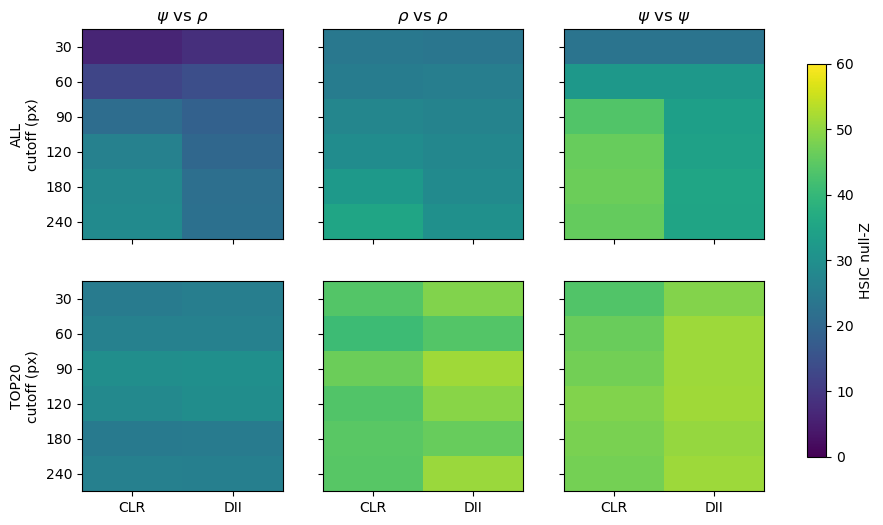

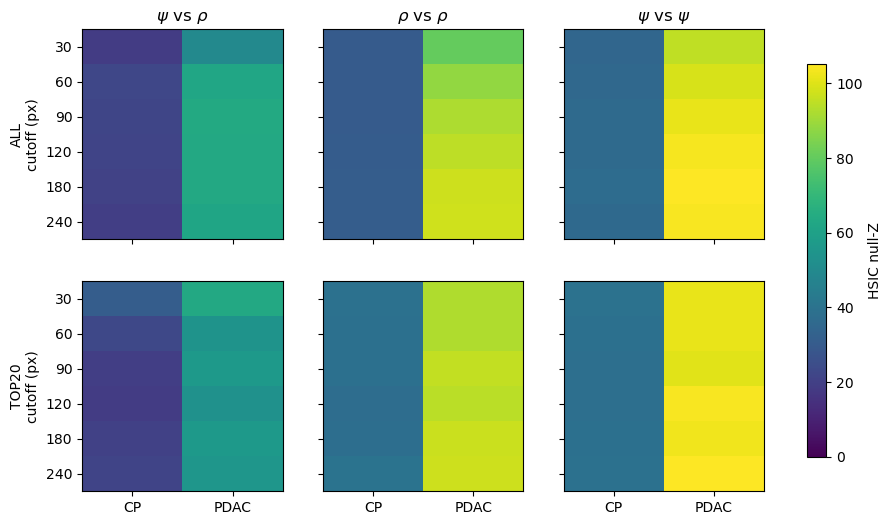

In [8]:
# Heatmap from the HSIC section of the paper.
#  One figure per dataset: rows = feature set (ALL / TOP20), columns = block
# pair. Each panel is a cutoff x pathology heatmap of the HSIC null-Z, with
# colour alone carrying the value (no cell annotations) on a shared per-dataset
# scale so panels are directly comparable. Figures are saved to ../figures/.
import matplotlib.pyplot as plt

FIG_DIR = Path.cwd().parent / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

PAIR_LABELS = {
    "psi-vs-dens": r"$\psi$ vs $\rho$",
    "dens-vs-dens": r"$\rho$ vs $\rho$",
    "psi-vs-psi": r"$\psi$ vs $\psi$",
}
FEATSETS = ["ALL", "TOP20"]
# Fixed colour ceilings per dataset; fall back to the observed max otherwise.
VMAX = {"CRC": 60.0}


def _pivot_block(dataset, featset, pair):
    sub = hsic_block_results[
        (hsic_block_results["dataset"] == dataset)
        & (hsic_block_results["featset"] == featset)
        & (hsic_block_results["pair"] == pair)
    ]
    mat = sub.pivot(index="cutoff", columns="split", values="z_score")
    return mat.reindex(index=HSIC_CUTOFFS, columns=SPLIT_ORDER[dataset])


for name in ["CRC", "CP_PDAC"]:
    vmax = VMAX.get(name, float(np.nanmax(
        hsic_block_results.loc[hsic_block_results["dataset"] == name, "z_score"]
    )))

    fig, axes = plt.subplots(len(FEATSETS), len(PAIRS),
                             figsize=(11, 6), sharex="col", sharey=True)
    for r, featset in enumerate(FEATSETS):
        for c, pair in enumerate(PAIRS):
            ax = axes[r, c]
            mat = _pivot_block(name, featset, pair)
            im = ax.imshow(mat.values, aspect="auto", cmap="viridis",
                           vmin=0.0, vmax=vmax)
            if r == 0:
                ax.set_title(PAIR_LABELS[pair])
            ax.set_xticks(range(mat.shape[1]))
            ax.set_xticklabels(mat.columns)
            ax.set_yticks(range(mat.shape[0]))
            ax.set_yticklabels(mat.index)
            if c == 0:
                ax.set_ylabel(f"{featset}\ncutoff (px)")

    fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.85, label="HSIC null-Z")
    fig.savefig(FIG_DIR / f"hsic_{name}.png", dpi=300, bbox_inches="tight")
    plt.show()